# 02 - Bias & Fairness Analysis

This notebook investigates potential fairness and bias issues in a loan approval dataset. The analysis follows several steps commonly used in algorithmic fairness assessments.

The goals of the notebook are:

- To measure potential **gender disparities** in loan approval outcomes.
- To evaluate whether **age groups experience different approval rates**.
- To investigate whether **non-protected variables act as indirect proxies** for protected attributes.
- To use **logistic regression** to determine whether demographic characteristics influence approval probability after controlling for financial factors.

Each section applies statistical methods to identify patterns that may indicate bias or indirect discrimination in automated or rule-based lending decisions.

In [143]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

df = pd.read_csv("credit_applications_curated.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (500, 32)


,_id,processing_timestamp,applicant_info.zip_code,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,...,Insurance,Travel,Transportation,Utilities,Groceries,Education,Adult Entertainment,Gambling,total_spend_monthly,loan_approved
0,app_200,2024-01-15T00:00:00Z,10036.0,23,0.20,31212,algorithm_risk_score,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1517.0,0
1,app_037,NaN,10032.0,51,0.18,17915,algorithm_risk_score,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,947.0,0
2,app_215,NaN,10075.0,41,0.21,37909,NaN,vacation,3.7,59000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,109.0,1
3,app_024,NaN,10077.0,70,0.35,0,NaN,NaN,4.3,34000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,575.0,1
4,app_184,2024-01-15T00:00:00Z,10080.0,14,0.23,31763,algorithm_risk_score,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,463.0,0


## 1) Disparate Impact Ratio (Gender)

Disparate Impact (DI), in this context, measures whether loan approval rates differ between male and female applicants.

Following the guideline in fairness analysis of the **four-fifths rule**, arriving at a ratio below **0.8** may indicate potential adverse impact, the following code calculates approval rates for each gender and computes the Disparate Impact ratio.

In [144]:
gender_counts = df["gender"].value_counts(dropna=False)

print("Gender distribution:")
print(gender_counts)

Gender distribution:
gender
Female     251
Male       247
Unknown      2
Name: count, dtype: int64


Approval Rate by gender

Before computing fairness metrics, it is useful to understand the **distribution of applicants across genders**. Large imbalances in group sizes can influence statistical interpretation and should be considered when evaluating fairness metrics.

In [145]:
approval_rates = df.groupby("gender")["loan_approved"].mean()

print("Approval rates by gender:")
print(approval_rates)

Approval rates by gender:
gender
Female     0.505976
Male       0.659919
Unknown    1.000000
Name: loan_approved, dtype: float64


Once approval rates are computed for each gender group, the Disparate Impact ratio can be calculated. In this case, the priveledged group are the males with more 15 percentage points of approval rate.

In [146]:
female_rate = approval_rates["Female"]
male_rate = approval_rates["Male"]

di_ratio = female_rate / male_rate

print("Female approval rate:", round(female_rate, 5))
print("Male approval rate:", round(male_rate, 5))
print("Disparate Impact Ratio:", round(di_ratio, 2))

Female approval rate: 0.50598
Male approval rate: 0.65992
Disparate Impact Ratio: 0.77


As the four-fifths rule states, DI≥0.8 is acceptable and DI<0.8 gives room to potential discrimination. 
Being 0.77 in our case, this suggests that there is in fact potential for gender-based disparate impact.

In [147]:
sub = df[df["gender"].isin(["Female", "Male"])]

female_n = (sub["gender"] == "Female").sum()
female_approvals = sub.loc[sub["gender"]=="Female", "loan_approved"].sum()

# Expected approvals if females had the same rate as males
expected_female = male_rate * female_n

shortfall = expected_female - female_approvals

print("Female applicants:", female_n)
print("Actual female approvals:", female_approvals)
print("Expected approvals at male rate:", round(expected_female,2))
print("Approval shortfall:", round(shortfall,2))

Female applicants: 251
Actual female approvals: 127
Expected approvals at male rate: 165.64
Approval shortfall: 38.64


While the Disparate Impact ratio measures the magnitude of disparity, it does not indicate whether the difference is statistically meaningful.

To evaluate whether approval outcomes are associated with gender beyond random variation, we perform the following **Chi-Square Test of Independence** for statistical evidence.

_H₀_: Approval is independent of gender

_H₁_: Approval is associated with gender

In [148]:
contingency_table = pd.crosstab(
    sub["gender"],
    sub["loan_approved"]
)

print(contingency_table)

loan_approved    0    1
gender                 
Female         124  127
Male            84  163


In [149]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2, 5))
print("p-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("\nWe reject the null hypothesis that approval decisions are independent of gender.")
else: print("\nWe fail to reject the null hypothesis that approval decisions are independent of gender.")

Chi-square statistic: 11.50525
p-value: 0.0006939983289861307
Degrees of freedom: 1

We reject the null hypothesis that approval decisions are independent of gender.


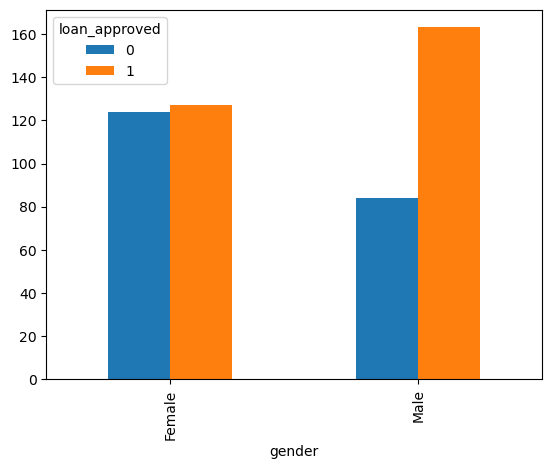

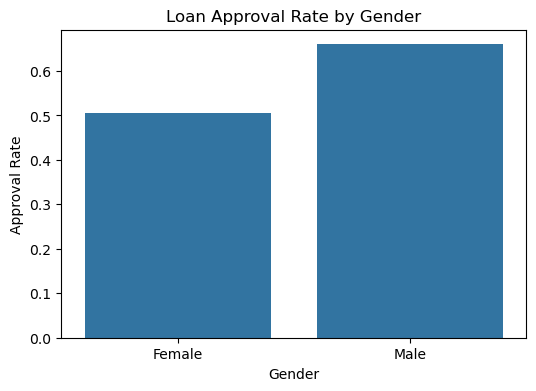

In [150]:
contingency_table.plot(kind="bar")
plt.figure(figsize=(6,4))
sns.barplot(data=approval_plot, x="gender", y="loan_approved")

plt.title("Loan Approval Rate by Gender")
plt.ylabel("Approval Rate")
plt.xlabel("Gender")

plt.show()

## 2) Age-based Bias Analysis

Age is another demographic attribute that may influence lending outcomes. Although age itself is often not used directly in decision models, related factors such as credit history length or income progression may introduce indirect age effects.

This section examines whether loan approval rates differ across age groups. The analysis proceeds in three steps:

1. Examine the **distribution of applicant ages**.
2. Group applicants into **age bins** to compare approval rates.
3. Test whether approval outcomes vary significantly across age groups using a **Chi-Square test**.

In [151]:
df["age"].describe()

count    339.000000
mean      41.044248
std       11.163171
min       23.000000
25%       32.000000
50%       39.000000
75%       47.500000
max       67.000000
Name: age, dtype: float64

Understanding the distribution of applicant ages helps determine how the dataset is structured and whether certain age ranges are over-represented. This can influence the interpretation of approval rates across age groups.

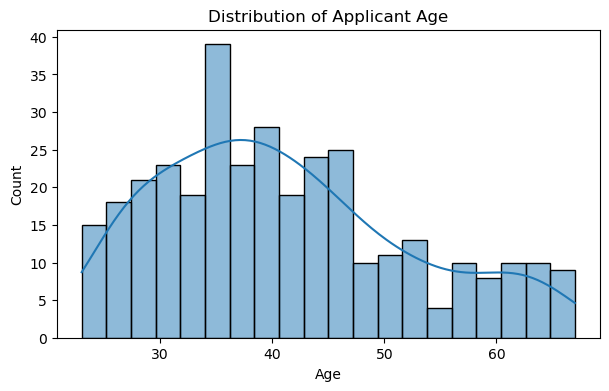

In [152]:
# Plot age distribution
plt.figure(figsize=(7,4))
sns.histplot(df["age"], bins=20, kde=True)

plt.title("Distribution of Applicant Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

To compare approval rates across ages, we divide applicants into **age groups (bins)**. Binning simplifies interpretation and allows statistical comparison between age categories rather than individual ages.

In [153]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,40,50,60,100],
    right=False
)

age_approval = df.groupby("age_group")["loan_approved"].mean()

print(age_approval)

age_group
[18, 30)     0.370370
[30, 40)     0.541667
[40, 50)     0.688889
[50, 60)     0.619048
[60, 100)    0.636364
Name: loan_approved, dtype: float64


C:\Users\jjoao\AppData\Local\Temp\ipykernel_39228\1701017812.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_approval = df.groupby("age_group")["loan_approved"].mean()


C:\Users\jjoao\AppData\Local\Temp\ipykernel_39228\2622738902.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_plot = df.groupby("age_group")["loan_approved"].mean().reset_index()


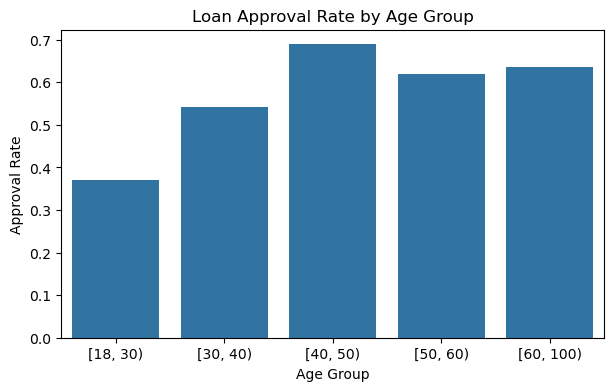

In [154]:
age_plot = df.groupby("age_group")["loan_approved"].mean().reset_index()

plt.figure(figsize=(7,4))
sns.barplot(data=age_plot, x="age_group", y="loan_approved")

plt.title("Loan Approval Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Approval Rate")

plt.show()

After computing approval rates by age group, we'll perform the following Chi-Square test to look at the statistical evidence of whether approval outcomes differ significantly across age categories. 

**Compute Chi-Square Test of Independence**

_H₀_: Approval outcome is independent of age group

_H₁_: Approval outcome is associated with the age group

In [155]:
age_table = pd.crosstab(
    df["age_group"],
    df["loan_approved"]
)

print(age_table)

loan_approved   0   1
age_group            
[18, 30)       34  20
[30, 40)       55  65
[40, 50)       28  62
[50, 60)       16  26
[60, 100)      12  21


In [156]:
chi2_age, p_age, dof_age, expected_age = chi2_contingency(age_table)

print("Chi-square statistic:", round(chi2_age, 5))
print("p-value:", p_age)

if p_age < 0.05:
    print("\nWe reject the null hypothesis that approval decisions are independent of age group.")
else : print("\nWe fail to reject the null hypothesis that approval decisions are independent of age group")

Chi-square statistic: 15.38167
p-value: 0.003971675721172353

We reject the null hypothesis that approval decisions are independent of age group.


## 3) Proxy Discrimination Analysis

Even when protected attributes such as gender or age are not explicitly used in decision models, other variables may indirectly encode demographic information.

This section explores potential proxy relationships by:

- examining correlations between demographic and financial variables
- identifying variables that may indirectly encode protected characteristics
- analyzing geographic indicators such as ZIP codes as potential socioeconomic proxies.

In [157]:
proxy_df = df.copy()

# Encode gender as binary
proxy_df["gender_binary"] = proxy_df["gender"].map({
    "Male": 1,
    "Female": 0
})

important_vars = [
    "loan_approved",
    "annual_income",
    "financials.debt_to_income",
    "financials.savings_balance",
    "financials.credit_history_months",
    "age",
    "gender_binary",
]

proxy_data = proxy_df[important_vars]

To identify potential proxy variables, we compute a **correlation matrix** among the previously separated key financial and demographic variables. A correlation analysis will help in revealing relationships between variables.

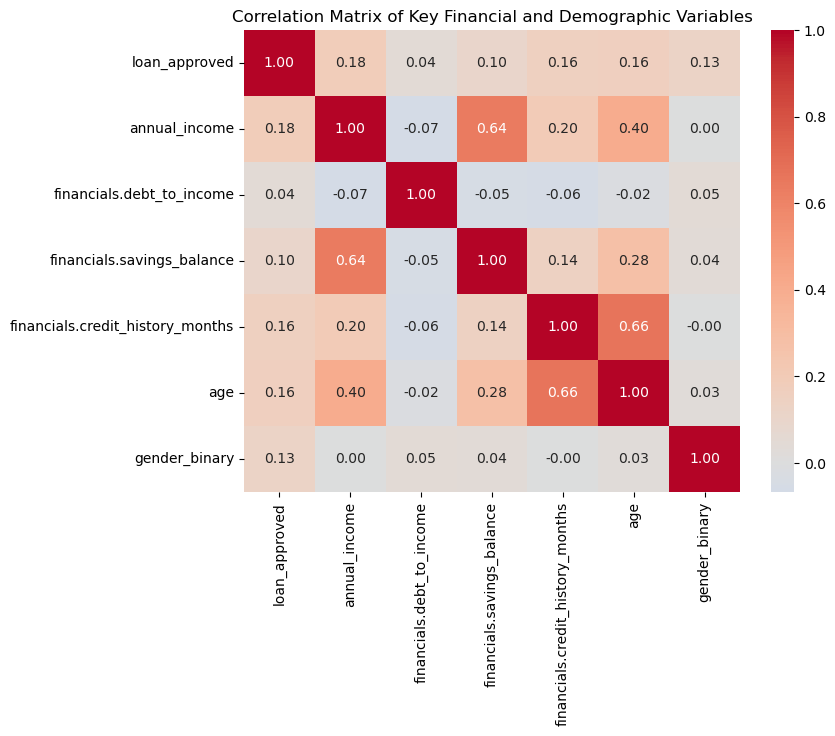

In [158]:
proxy_data_clean = proxy_data.dropna().copy()
corr_matrix = proxy_data_clean.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of Key Financial and Demographic Variables")
plt.show()

### Geographic Proxy Analysis

ZIP codes represent geographic identifiers rather than numerical quantities with inherent order. Because geographic location often correlates with socioeconomic characteristics such as income levels, housing markets, or neighborhood demographics, ZIP codes can sometimes act as indirect proxies.

Instead of treating ZIP codes as continuous variables, we analyze approval rates by geographic group and test whether approval outcomes vary significantly across regions.

In [159]:
zip_approval = df.groupby("applicant_info.zip_code")["loan_approved"].mean()

zip_approval.sort_values().head()
zip_approval.sort_values().tail()


applicant_info.zip_code
90244.0    1.0
90245.0    1.0
90295.0    1.0
90291.0    1.0
90289.0    1.0
Name: loan_approved, dtype: float64

In [160]:
df["zip3"] = df["applicant_info.zip_code"].astype(str).str[:3]

zip3_rates = df.groupby("zip3")["loan_approved"].mean()

zip3_rates.sort_values()

zip3
902    0.517391
300    0.555556
100    0.645418
nan    1.000000
Name: loan_approved, dtype: float64

To evaluate whether loan approvals vary across geographic regions, we perform a Chi-Square test between ZIP code regions and approval outcomes.



**Compute Chi-Square Test of Independence** for statistical evidence

_H₀_: Approval outcome is independent of ZIP code (region)

_H₁_: Approval outcome is associated with the ZIP code (region)

In [161]:
zip_table = pd.crosstab(df["zip3"], df["loan_approved"])

chi2, p_zipcode, dof, expected = chi2_contingency(zip_table)

print("Chi-square:", round(chi2, 5))
print("p-value:", p_zipcode)

if p_age < 0.05:
    print("\nWe reject the null hypothesis that approval decisions are independent of ZIP code (region).")
else : print("\nWe fail to reject the null hypothesis that approval decisions are independent of of ZIP code (region).")

Chi-square: 8.8699
p-value: 0.031071551000392255

We reject the null hypothesis that approval decisions are independent of ZIP code (region).


# 4) Logistic Regression

While previous sections examine disparities using descriptive statistics and hypothesis testing, these logistic regression will allows us to analyze how multiple variables jointly influence approval probability.

This section estimates three models:

1. **Baseline model:** 
2. **Controlled model:** 
3. **Interaction model:**

This approach helps distinguish between disparities driven by financial characteristics and those potentially associated with demographic attributes.

The first model estimates the relationship between gender and approval probability without controlling for other variables.

In [162]:
y = proxy_data_clean['loan_approved']

X1 = sm.add_constant(proxy_data_clean[['gender_binary']])
model1 = sm.Logit(y, X1).fit()
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.674908
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          loan_approved   No. Observations:                  338
Model:                          Logit   Df Residuals:                      336
Method:                           MLE   Df Model:                            1
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                 0.01189
Time:                        10:56:52   Log-Likelihood:                -228.12
converged:                       True   LL-Null:                       -230.86
Covariance Type:            nonrobust   LLR p-value:                   0.01913
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0351      0.153      0.229      0.819      -0.265       0.335
gender_binary     0.

The second model introduces financial variables such as income, debt-to-income ratio, savings balance, and credit history length. These variables represent legitimate indicators of creditworthiness and allow us to evaluate the gender effect while holding financial characteristics constant.

In [163]:
X2 = sm.add_constant(proxy_data_clean[[
    'gender_binary',
    'age',
    'annual_income',
    'financials.debt_to_income',
    'financials.savings_balance',
    'financials.credit_history_months'
]])
model2 = sm.Logit(y, X2).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.647484
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          loan_approved   No. Observations:                  338
Model:                          Logit   Df Residuals:                      331
Method:                           MLE   Df Model:                            6
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                 0.05204
Time:                        10:56:52   Log-Likelihood:                -218.85
converged:                       True   LL-Null:                       -230.86
Covariance Type:            nonrobust   LLR p-value:                 0.0005160
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -1.6753      0.549     -3.05

Finally, the third model was built to explore whether gender differences vary across age groups. To do this, an interaction variable between gender and age is created. Interaction terms allow the model to capture situations where the effect of one variable depends on the value of another variable.

In [165]:
proxy_data_clean['gender_age'] = proxy_data_clean['gender_binary'] * proxy_data_clean['age']

X3 = sm.add_constant(proxy_data_clean[[
    'gender_binary',
    'age',
    'gender_age',
    'annual_income',
    'financials.debt_to_income',
    'financials.savings_balance',
    'financials.credit_history_months'
]])
model3 = sm.Logit(y, X3).fit()
print(model3.summary())

Optimization terminated successfully.
         Current function value: 0.647200
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          loan_approved   No. Observations:                  338
Model:                          Logit   Df Residuals:                      330
Method:                           MLE   Df Model:                            7
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                 0.05246
Time:                        10:56:52   Log-Likelihood:                -218.75
converged:                       True   LL-Null:                       -230.86
Covariance Type:            nonrobust   LLR p-value:                  0.001042
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -1.5196      0.652     -2.33

Logistic regression coefficients are expressed in log-odds, which may difficult to interpret directly. By exponentiating the coefficients, we convert them into **odds ratios**, which represent the multiplicative change in approval odds associated with each variable.

In [166]:
odds_ratios = np.exp(model3.params)
print(odds_ratios)

const                               0.218789
gender_binary                       1.180491
age                                 0.997662
gender_age                          1.009241
annual_income                       1.000014
financials.debt_to_income           2.277958
financials.savings_balance          0.999994
financials.credit_history_months    1.008515
dtype: float64


## Interpretation of Fairness Results

The analysis indicates differences in loan approval rates across demographic groups. For example, approval rates vary between gender categories and across age groups.

While such differences do not necessarily imply intentional discrimination, they highlight the importance of monitoring potential bias in automated decision systems.

From a governance perspective, organizations deploying credit scoring models should regularly evaluate fairness metrics and investigate whether observed disparities reflect legitimate financial risk factors or unintended biases embedded in historical data.

## Bias Analysis Conclusion

This notebook evaluated potential fairness risks in the credit approval dataset by analyzing approval outcomes across demographic attributes.

The results suggest that approval rates differ across some demographic groups, which may warrant further investigation. In real-world systems, such findings would require continuous monitoring and governance oversight to ensure that automated decisions remain fair and transparent.